<a href="https://colab.research.google.com/github/JFcamp/rag-plantas-medicinais/blob/main/explicabilidade_e_comparativo_rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔬 Por dentro do RAG de Plantas: mapa de calor e LLM com × sem RAG

Notebook **independente**: baixa as fotos, treina o classificador, monta o RAG e abre a caixa-preta em duas frentes:

1. **Grad-CAM (mapa de calor):** mostra **onde a CNN olhou** na foto para decidir qual é a planta. Dá para ver se ela olhou a folha, a flor ou... o fundo.
2. **LLM com RAG × sem RAG:** a mesma pergunta vai para o **mesmo Qwen2.5-3B**, uma vez sozinho e outra com as páginas do guia. Os números das respostas (doses, tempos, quantidades) são conferidos no PDF: 🟩 aparece no guia, 🟥 não aparece.

```
foto ──► EfficientNet ──► Grad-CAM ──► "olhou para a borda serrilhada da folha"
pergunta ──┬──► Qwen sozinho ─────────────────► resposta A  ┐
           └──► busca no PDF ──► Qwen + páginas ─► resposta B ┴──► números conferidos no guia
```

### ⚙️ Antes de começar
- **Ambiente de execução → Alterar o tipo de ambiente de execução → T4 GPU**.
- Rode as células **em ordem**. Na primeira vez, baixar as fotos e treinar leva uns 10 a 15 minutos.
- O modelo treinado fica salvo no seu **Google Drive** (`MyDrive/minicurso_plantas/`). Da segunda vez em diante, o notebook **pula o download e o treino** e carrega o modelo em segundos. Ótimo para o dia do minicurso.
- O guia em PDF é baixado do repositório público (só leitura). Se preferir, deixe `URL_PDF = ""` e envie o PDF pelo upload.

> ⚠️ **Projeto educativo.** A IA pode errar, e as respostas não substituem a orientação de profissionais de saúde.

---
## Parte 0 · Preparação

In [1]:
# 1 · Instalação e GPU
!pip install -q -U transformers accelerate sentence-transformers faiss-cpu pypdf

import torch
assert torch.cuda.is_available(), "⚠️ GPU não encontrada: Ambiente de execução → Alterar o tipo → T4 GPU"
print("GPU:", torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.5/395.5 kB 21.4 MB/s eta 0:00:00
GPU: Tesla T4


In [2]:
# 2 · Configurações
device = "cuda"

# Arquivos
USAR_DRIVE  = True    # salva/carrega o modelo treinado no Google Drive (evita treinar de novo)
PASTA_DRIVE = "/content/drive/MyDrive/minicurso_plantas"
URL_PDF     = "https://github.com/JFcamp/rag-plantas-medicinais/raw/main/guia_plantas_medicinais.pdf"  # "" = upload
MODELO_IMG_PATH = "modelo_plantas.pt"
PDF_PATH        = "guia_plantas_medicinais.pdf"

# Dataset e treino (valores menores que os do notebook principal, para treinar mais rápido)
FOTOS_POR_ESPECIE = 200
PASTA_DATASET = "dataset_plantas"
LICENCAS = ["cc0", "cc-by", "cc-by-nc"]
BATCH, EPOCAS = 32, 6

# pasta: (nome em português, id do táxon no iNaturalist), igual ao notebook principal
ESPECIES = {
    "alecrim": ("Alecrim", 636795),
    "babosa": ("Babosa", 126882),
    "boldo": ("Boldo-brasileiro", 157127),
    "calendula": ("Calêndula", 75931),
    "camomila": ("Camomila", 77965),
    "capim_limao": ("Capim-limão", 123728),
    "erva_cidreira_lippia": ("Erva-cidreira-brasileira (lípia)", 223926),
    "espinheira_santa": ("Espinheira-santa", 431288),
    "gengibre": ("Gengibre", 122971),
    "hortela": ("Hortelã", 54570),
    "manjericao": ("Manjericão", 61398),
    "melissa": ("Melissa (erva-cidreira)", 59901),
    "tanchagem": ("Tanchagem", 58961),
    "vinagreira": ("Vinagreira (hibisco)", 1687652),
}
IMG_SIZE = 224
LIMIAR_CONFIANCA = 0.50

# RAG (mesmos valores do notebook principal)
EMBEDDER_ID = "intfloat/multilingual-e5-base"
LLM_ID = "Qwen/Qwen2.5-3B-Instruct"
CHUNK_TAMANHO, CHUNK_SOBREPOSICAO = 800, 150
TOP_K_CHUNKS = 6
MAX_PAGINAS = 3
MAX_NOVOS_TOKENS = 400

SYSTEM_PROMPT_RAG = (
    "Você é um assistente educativo que responde perguntas sobre plantas medicinais usando um guia. "
    "Use SOMENTE as informações dos trechos fornecidos. "
    "Se a resposta não estiver nos trechos, diga exatamente: "
    "\"Não encontrei essa informação no documento.\" "
    "Não invente dados, doses ou indicações. Quando a pergunta for sobre como usar, preparar ou a dose de uma planta, "
    "informe também as principais contraindicações que aparecem nos trechos e lembre que o uso deve ser orientado "
    "por um profissional de saúde. Responda em português, de forma direta e organizada, "
    "e indique a(s) página(s) de onde tirou a informação, no formato (pág. X)."
)
# Sem RAG: o mesmo modelo, sem documento. O prompt é neutro para a comparação ser justa.
SYSTEM_PROMPT_SEM_RAG = (
    "Você é um assistente educativo sobre plantas medicinais. "
    "Responda em português, de forma direta e organizada."
)
print("✅ Configurações carregadas.")

✅ Configurações carregadas.


In [3]:
# 3 · Google Drive (cache do modelo) + guia em PDF
import os, shutil, requests

if USAR_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    os.makedirs(PASTA_DRIVE, exist_ok=True)
    no_drive = os.path.join(PASTA_DRIVE, MODELO_IMG_PATH)
    if os.path.exists(no_drive) and not os.path.exists(MODELO_IMG_PATH):
        shutil.copy(no_drive, MODELO_IMG_PATH)

MODELO_PRONTO = os.path.exists(MODELO_IMG_PATH)
print("✅ Modelo já treinado encontrado: download e treino serão pulados." if MODELO_PRONTO
      else "ℹ️ Nenhum modelo salvo ainda: as próximas células baixam as fotos e treinam.")

if not os.path.exists(PDF_PATH):
    r = requests.get(URL_PDF, timeout=120) if URL_PDF else None
    if r is not None and r.status_code == 200 and r.content[:4] == b"%PDF":
        open(PDF_PATH, "wb").write(r.content)
    else:
        from google.colab import files
        print("📤 Envie o guia em PDF:")
        nome = list(files.upload().keys())[0]
        os.rename(nome, PDF_PATH)
print(f"✅ PDF pronto: {PDF_PATH}")

Mounted at /content/drive
ℹ️ Nenhum modelo salvo ainda: as próximas células baixam as fotos e treinam.
✅ PDF pronto: guia_plantas_medicinais.pdf


---
## Parte 1 · Treinar o classificador

Fotos reais do **iNaturalist** (identificadas pela comunidade, só licenças abertas) e fine-tuning da **EfficientNet-B0** pré-treinada no ImageNet. Se o modelo já estiver no Drive, as duas células abaixo são puladas.

In [4]:
# 4 · Baixar as fotos do iNaturalist (cerca de 5 minutos; pulado se o modelo já existir)
import time, csv, io
import concurrent.futures as cf
from PIL import Image

H = {"User-Agent": "minicurso-rag-plantas-medicinais/1.0 (uso educacional)"}
API = "https://api.inaturalist.org/v1/observations"

def chamar_api(params, tentativas=5):
    for t in range(tentativas):
        try:
            r = requests.get(API, params=params, headers=H, timeout=30)
            if r.status_code == 200:
                time.sleep(1.1)   # limite de ~1 requisição/segundo da API
                return r.json()
        except requests.RequestException:
            pass
        time.sleep(5 * (t + 1))
    raise RuntimeError("Falha ao acessar o iNaturalist. Rode a célula de novo (ela continua de onde parou).")

def listar_fotos(taxon_id, alvo):
    fotos, vistas = [], set()
    for grau in ("research", "needs_id", "casual"):
        id_abaixo = None
        while len(fotos) < alvo:
            p = dict(taxon_id=taxon_id, photos="true", photo_license=",".join(LICENCAS),
                     quality_grade=grau, per_page=200, order_by="id", order="desc")
            if id_abaixo:
                p["id_below"] = id_abaixo
            obs = chamar_api(p)["results"]
            if not obs:
                break
            for o in obs:
                for f in o["photos"]:
                    if (f.get("license_code") or "") in LICENCAS and f["id"] not in vistas:
                        vistas.add(f["id"])
                        fotos.append({"obs": o["id"], "foto": f["id"], "url": f["url"].replace("square", "medium"),
                                      "licenca": f.get("license_code"), "autor": f.get("attribution", "")})
                        break
                if len(fotos) >= alvo:
                    break
            id_abaixo = obs[-1]["id"]
        if len(fotos) >= alvo:
            break
    return fotos

def baixar(item, pasta):
    caminho = os.path.join(pasta, f"{item['obs']}_{item['foto']}.jpg")
    if os.path.exists(caminho):
        return caminho
    for _ in range(3):
        try:
            img = Image.open(io.BytesIO(requests.get(item["url"], headers=H, timeout=30).content)).convert("RGB")
            img.thumbnail((512, 512)); img.save(caminho, quality=90)
            return caminho
        except Exception:
            time.sleep(2)
    return None

if MODELO_PRONTO:
    print("⏭️ Modelo já existe: download pulado.")
else:
    creditos = []
    for pasta_classe, (nome, taxon_id) in ESPECIES.items():
        pasta = os.path.join(PASTA_DATASET, pasta_classe); os.makedirs(pasta, exist_ok=True)
        fotos = listar_fotos(taxon_id, FOTOS_POR_ESPECIE)
        with cf.ThreadPoolExecutor(max_workers=8) as ex:
            caminhos = list(ex.map(lambda it: baixar(it, pasta), fotos))
        for it, c in zip(fotos, caminhos):
            if c:
                creditos.append({"classe": pasta_classe, "arquivo": c, "autor": it["autor"], "licenca": it["licenca"],
                                 "observacao": f"https://www.inaturalist.org/observations/{it['obs']}"})
        print(f"{nome:34s} {sum(1 for c in caminhos if c):4d} fotos")
    with open("creditos.csv", "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=creditos[0].keys()); w.writeheader(); w.writerows(creditos)
    print(f"\n✅ {len(creditos)} fotos baixadas. Créditos em creditos.csv")

Alecrim                             200 fotos
Babosa                              200 fotos
Boldo-brasileiro                    200 fotos
Calêndula                           200 fotos
Camomila                            200 fotos
Capim-limão                         200 fotos
Erva-cidreira-brasileira (lípia)    200 fotos
Espinheira-santa                    200 fotos
Gengibre                            200 fotos
Hortelã                             200 fotos
Manjericão                          200 fotos
Melissa (erva-cidreira)             200 fotos
Tanchagem                           200 fotos
Vinagreira (hibisco)                200 fotos

✅ 2800 fotos baixadas. Créditos em creditos.csv


In [5]:
# 5 · Fine-tuning da EfficientNet-B0 (cerca de 4 minutos na T4; pulado se o modelo já existir)
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from sklearn.model_selection import train_test_split

MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
recorte = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(IMG_SIZE)])   # o que o modelo "vê"
tf_val = transforms.Compose([recorte, transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
amostras_val = {}   # fotos que o modelo NÃO viu no treino (usadas na galeria do Grad-CAM)

if MODELO_PRONTO:
    print("⏭️ Modelo já existe: treino pulado.")
else:
    tf_treino = transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.5, 1.0)), transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15), transforms.ColorJitter(0.25, 0.25, 0.25),
        transforms.ToTensor(), transforms.Normalize(MEAN, STD)])
    base_treino = datasets.ImageFolder(PASTA_DATASET, transform=tf_treino)
    base_val = datasets.ImageFolder(PASTA_DATASET, transform=tf_val)
    idx_treino, idx_val = train_test_split(list(range(len(base_treino))), test_size=0.15,
                                           stratify=base_treino.targets, random_state=42)
    dl_treino = DataLoader(Subset(base_treino, idx_treino), batch_size=BATCH, shuffle=True, num_workers=2)
    dl_val = DataLoader(Subset(base_val, idx_val), batch_size=64, num_workers=2)
    for i in idx_val:
        caminho, y = base_val.samples[i]
        amostras_val.setdefault(base_val.classes[y], []).append(caminho)

    m = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, len(base_treino.classes))
    m = m.to(device)
    criterio = nn.CrossEntropyLoss(label_smoothing=0.1)
    otim = torch.optim.AdamW(m.parameters(), lr=3e-4, weight_decay=1e-4)
    agenda = torch.optim.lr_scheduler.CosineAnnealingLR(otim, T_max=EPOCAS)
    scaler = torch.amp.GradScaler("cuda")
    melhor = 0.0
    for ep in range(1, EPOCAS + 1):
        m.train(); t0 = time.time()
        for x, y in dl_treino:
            x, y = x.to(device), y.to(device); otim.zero_grad()
            with torch.amp.autocast("cuda"):
                perda = criterio(m(x), y)
            scaler.scale(perda).backward(); scaler.step(otim); scaler.update()
        agenda.step()
        m.eval(); acertos = 0
        with torch.no_grad(), torch.amp.autocast("cuda"):
            for x, y in dl_val:
                acertos += (m(x.to(device)).argmax(1).cpu() == y).sum().item()
        acc = acertos / len(idx_val); marca = ""
        if acc > melhor:
            melhor = acc; marca = "  💾 salvo"
            torch.save({"state_dict": m.state_dict(), "classes": base_treino.classes}, MODELO_IMG_PATH)
        print(f"Época {ep}/{EPOCAS} | acurácia validação: {acc:.2%} | {time.time()-t0:.0f}s{marca}")
    del m, otim, scaler; torch.cuda.empty_cache()
    if USAR_DRIVE:
        shutil.copy(MODELO_IMG_PATH, os.path.join(PASTA_DRIVE, MODELO_IMG_PATH))
        print(f"☁️ Modelo salvo no Drive: {PASTA_DRIVE}/{MODELO_IMG_PATH}")
    print(f"\n🏆 Melhor acurácia de validação: {melhor:.2%}")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 161MB/s]


Época 1/6 | acurácia validação: 81.67% | 30s  💾 salvo
Época 2/6 | acurácia validação: 88.81% | 20s  💾 salvo
Época 3/6 | acurácia validação: 90.00% | 21s  💾 salvo
Época 4/6 | acurácia validação: 89.76% | 19s
Época 5/6 | acurácia validação: 90.48% | 20s  💾 salvo
Época 6/6 | acurácia validação: 91.19% | 21s  💾 salvo
☁️ Modelo salvo no Drive: /content/drive/MyDrive/minicurso_plantas/modelo_plantas.pt

🏆 Melhor acurácia de validação: 91.19%


---
## Parte 2 · Grad-CAM: onde a CNN está olhando?

A EfficientNet termina num bloco convolucional que gera **1280 mapas de 7×7**. Cada mapa "acende" quando encontra um padrão (uma nervura, uma borda serrilhada, uma pétala amarela...).

O **Grad-CAM** (Selvaraju et al., 2017) pergunta: *se esse mapa aumentar, a nota da classe "Hortelã" sobe quanto?* Esse quanto é o **gradiente**. A gente faz uma média ponderada dos mapas usando os gradientes como peso, fica só com a parte positiva (ReLU) e amplia o resultado de 7×7 para o tamanho da foto.

$$L^{c}_{\text{Grad-CAM}} = \mathrm{ReLU}\Big(\sum_k \alpha_k^c A^k\Big), \qquad \alpha_k^c = \frac{1}{Z}\sum_{i,j}\frac{\partial y^c}{\partial A^k_{ij}}$$

🔴 vermelho = região que mais pesou na decisão · 🔵 azul = região ignorada.

In [6]:
# 6 · Carregar o classificador treinado
import numpy as np, matplotlib.pyplot as plt
import torch.nn as nn, torch.nn.functional as F
from PIL import Image
from torchvision.models import efficientnet_b0

ckpt = torch.load(MODELO_IMG_PATH, map_location=device)
CLASSES = ckpt["classes"]
NOMES = [ESPECIES[c][0] for c in CLASSES]

modelo_img = efficientnet_b0()
modelo_img.classifier[1] = nn.Linear(modelo_img.classifier[1].in_features, len(CLASSES))
modelo_img.load_state_dict(ckpt["state_dict"])
modelo_img = modelo_img.to(device).eval()

print(f"✅ Classificador carregado: {len(CLASSES)} plantas.")

✅ Classificador carregado: 14 plantas.


In [7]:
# 7 · Grad-CAM implementado do zero (sem biblioteca extra)
class GradCAM:
    def __init__(self, modelo, camada):
        self.modelo, self.ativacoes, self.gradientes = modelo, None, None
        camada.register_forward_hook(self._guardar)

    def _guardar(self, modulo, entrada, saida):
        self.ativacoes = saida                      # A^k: mapas da última camada convolucional (1280×7×7)
        if saida.requires_grad:
            saida.register_hook(lambda g: setattr(self, "gradientes", g))   # ∂y^c/∂A^k

    def __call__(self, x, classe):
        self.modelo.zero_grad()
        logits = self.modelo(x)
        logits[0, classe].backward()
        pesos = self.gradientes.mean(dim=(2, 3), keepdim=True)          # α_k^c: média do gradiente em cada mapa
        cam = F.relu((pesos * self.ativacoes).sum(dim=1, keepdim=True)) # soma ponderada + ReLU
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)[0, 0]
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam.detach().cpu().numpy()

gradcam = GradCAM(modelo_img, modelo_img.features[-1])

def classificar(img):
    with torch.no_grad():
        return F.softmax(modelo_img(tf_val(img).unsqueeze(0).to(device)).float(), dim=1)[0].cpu()

def mostrar_gradcam(img, titulo=""):
    """Foto | por que é a 1ª opção | por que poderia ser a 2ª | top 5."""
    img = img.convert("RGB")
    x = tf_val(img).unsqueeze(0).to(device)
    probs = classificar(img)
    top = probs.topk(5)
    c1, c2 = int(top.indices[0]), int(top.indices[1])
    cam1, cam2 = gradcam(x, c1), gradcam(x, c2)
    vista = recorte(img)

    fig, ax = plt.subplots(1, 4, figsize=(19, 4.8), gridspec_kw={"width_ratios": [1, 1, 1, 1.15]})
    ax[0].imshow(vista); ax[0].set_title(titulo or "Foto (como o modelo vê)")
    for a, cam, c in ((ax[1], cam1, c1), (ax[2], cam2, c2)):
        a.imshow(vista); a.imshow(cam, cmap="jet", alpha=0.45)
        a.set_title(f"Por que seria {NOMES[c]}? ({probs[c]:.0%})", fontsize=10)
    for a in ax[:3]:
        a.axis("off")
    cores = ["#2e7d32"] + ["#9e9e9e"] * 4
    ax[3].barh([NOMES[i] for i in top.indices][::-1], top.values.numpy()[::-1], color=cores[::-1])
    ax[3].axvline(LIMIAR_CONFIANCA, ls="--", c="#c62828", lw=1); ax[3].set_xlim(0, 1)
    ax[3].set_title("Top 5 (linha vermelha = limiar de confiança)", fontsize=10)
    plt.tight_layout(); plt.show()

    if top.values[0] < LIMIAR_CONFIANCA:
        print(f"⚠️ Confiança baixa ({top.values[0]:.0%}). Talvez não seja uma das 14 plantas, ou a foto não mostra bem as folhas.")
        return None
    return NOMES[c1]

print("✅ Grad-CAM pronto.")

✅ Grad-CAM pronto.


📷 Envie uma ou mais fotos de plantas:


Saving babosa-1-0aom3nptmt (2).jpg to babosa-1-0aom3nptmt (2).jpg


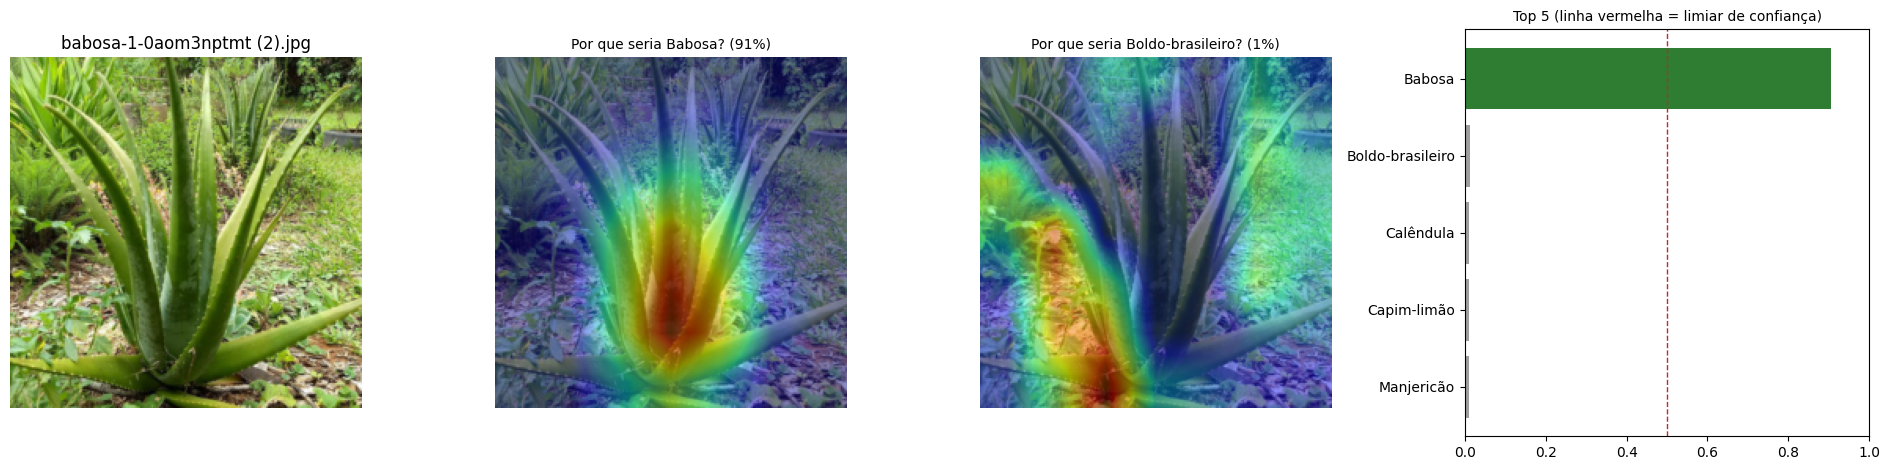

In [8]:
# 8 · Teste com a SUA foto (celular, Google, a planta no vaso da sala...)
from google.colab import files
print("📷 Envie uma ou mais fotos de plantas:")
for nome in files.upload():
    mostrar_gradcam(Image.open(nome), titulo=nome[:30])

### As plantas que o modelo mais confunde

No teste, **hortelã, manjericão e melissa** tiveram o menor F1 (0,84 a 0,91). As três têm folhas verdes, ovais e com borda serrilhada. O Grad-CAM mostra se o modelo encontrou algo que diferencia uma da outra ou se está "chutando" pelo formato geral.

*Se você treinou nesta sessão, as fotos vêm da **validação** (o modelo nunca as viu no treino). Se o modelo veio do Drive, vêm do iNaturalist e podem ter sido usadas no treino; aí o objetivo é só ver **onde** o modelo olha.*

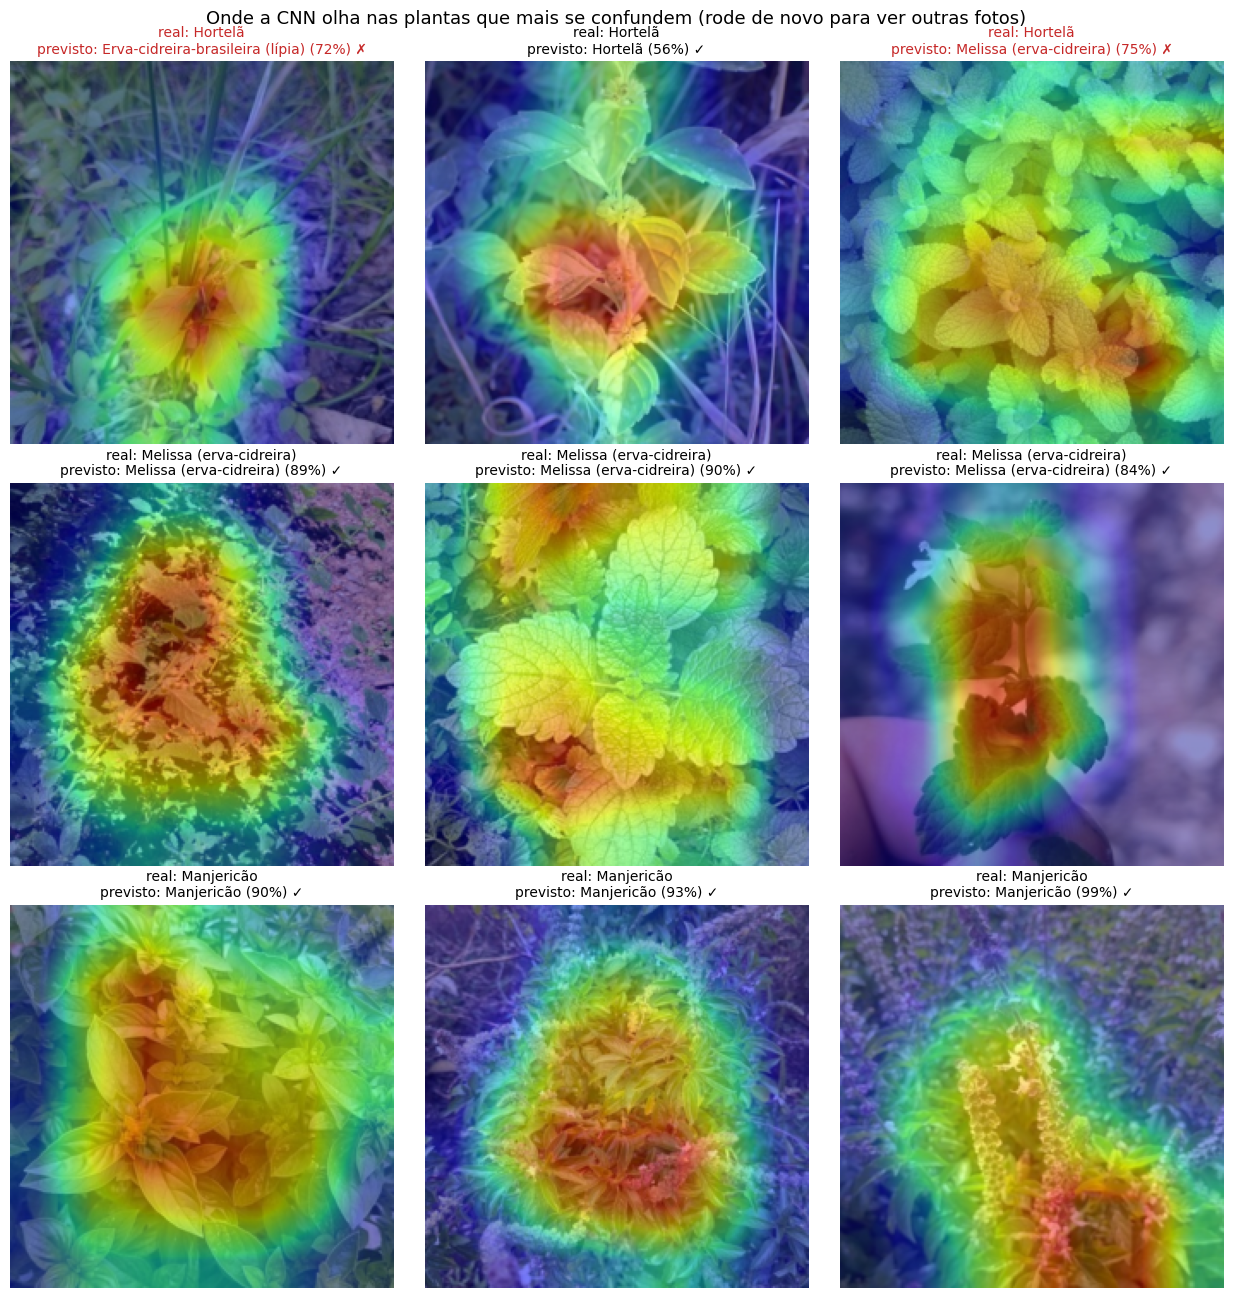

In [9]:
# 9 · Galeria: Grad-CAM nas plantas parecidas
import io, random

H = {"User-Agent": "minicurso-rag-plantas-medicinais/1.0 (uso educacional)"}

def fotos_inaturalist(taxon_id, n=3):
    p = dict(taxon_id=taxon_id, photos="true", quality_grade="research", photo_license="cc0,cc-by,cc-by-nc",
             per_page=n, page=random.randint(1, 20))
    obs = requests.get("https://api.inaturalist.org/v1/observations", params=p, headers=H, timeout=30).json()["results"]
    imgs = []
    for o in obs:
        url = o["photos"][0]["url"].replace("square", "medium")
        imgs.append(Image.open(io.BytesIO(requests.get(url, headers=H, timeout=30).content)).convert("RGB"))
    return imgs

PARECIDAS = ["hortela", "melissa", "manjericao"]   # troque por outras pastas de ESPECIES, se quiser
N = 3
fig, axes = plt.subplots(len(PARECIDAS), N, figsize=(4.2 * N, 4.4 * len(PARECIDAS)))
for linha, pasta in enumerate(PARECIDAS):
    if amostras_val.get(pasta):
        imgs = [Image.open(c).convert("RGB") for c in random.sample(amostras_val[pasta], N)]
    else:
        imgs = fotos_inaturalist(ESPECIES[pasta][1], N)
    for col, img in enumerate(imgs):
        x = tf_val(img).unsqueeze(0).to(device)
        probs = classificar(img); c = int(probs.argmax())
        ax = axes[linha, col]
        ax.imshow(recorte(img)); ax.imshow(gradcam(x, c), cmap="jet", alpha=0.45); ax.axis("off")
        certo = NOMES[c] == ESPECIES[pasta][0]
        ax.set_title(f"real: {ESPECIES[pasta][0]}\nprevisto: {NOMES[c]} ({probs[c]:.0%}) {'✓' if certo else '✗'}",
                     fontsize=10, color="black" if certo else "#c62828")
plt.suptitle("Onde a CNN olha nas plantas que mais se confundem (rode de novo para ver outras fotos)", fontsize=13)
plt.tight_layout(); plt.show()

**Para discutir com a turma:**
- O vermelho cai na **folha** ou no **fundo** (vaso, mão, terra)? Se cair no fundo, o modelo aprendeu um atalho (*shortcut learning*), e isso não aparece na acurácia.
- Nos erros, o mapa da 2ª opção costuma ficar parecido com o da 1ª. É a "dúvida" do modelo desenhada na foto.

---
## Parte 3 · O mesmo LLM com RAG e sem RAG

Sem RAG, o Qwen responde com o que "lembra" do treino, e um modelo de 3B lembra pouco sobre fitoterápicos brasileiros. O risco é ele responder com **segurança** e **números inventados**. Em dose de planta medicinal, isso é perigoso.

Com RAG, ele recebe as páginas do guia (baseado no Formulário de Fitoterápicos da ANVISA) e só pode usar o que está nelas.

**Como a verificação funciona:** cada quantidade com unidade nas respostas (`2 g`, `150 mL`, `3 vezes`, `7 dias`...) é procurada no texto do guia inteiro.
🟩 aparece no guia · 🟥 não aparece em nenhuma página. É uma checagem automática simples: ela mostra **de onde o número pode ter vindo**, não se a frase está correta.

In [10]:
# 10 · Carregar embeddings + LLM (cerca de 2 minutos)
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForCausalLM

embedder = SentenceTransformer(EMBEDDER_ID, device=device)
tokenizer = AutoTokenizer.from_pretrained(LLM_ID)
llm = AutoModelForCausalLM.from_pretrained(LLM_ID, dtype=torch.float16, device_map=device).eval()
print(f"✅ Modelos carregados. Memória GPU: {torch.cuda.memory_allocated() / 1e9:.1f} GB")

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/179k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.11GB            

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✅ Modelos carregados. Memória GPU: 7.4 GB


In [11]:
# 11 · Indexar o PDF e preparar as duas versões do assistente
import re, time, faiss
from pypdf import PdfReader

def dividir_em_chunks(texto, tamanho=CHUNK_TAMANHO, sobreposicao=CHUNK_SOBREPOSICAO):
    chunks, inicio = [], 0
    while inicio < len(texto):
        fim = min(inicio + tamanho, len(texto))
        if fim < len(texto):
            corte = max(texto.rfind(" ", inicio, fim), texto.rfind("\n", inicio, fim))
            if corte > inicio + tamanho // 2:
                fim = corte
        chunks.append(texto[inicio:fim].strip())
        if fim >= len(texto):
            break
        inicio = fim - sobreposicao
    return [c for c in chunks if c]

textos_paginas, chunks = {}, []
for i, page in enumerate(PdfReader(PDF_PATH).pages, start=1):
    t = re.sub(r"[ \t]+", " ", page.extract_text() or "")
    textos_paginas[i] = re.sub(r"\n{3,}", "\n\n", t).strip()
    for c in dividir_em_chunks(textos_paginas[i]):
        chunks.append({"pagina": i, "texto": c})
emb = np.asarray(embedder.encode(["passage: " + c["texto"] for c in chunks], normalize_embeddings=True), dtype="float32")
index = faiss.IndexFlatIP(emb.shape[1]); index.add(emb)

def buscar(pergunta, k=TOP_K_CHUNKS):
    q = np.asarray(embedder.encode(["query: " + pergunta], normalize_embeddings=True), dtype="float32")
    scores, ids = index.search(q, k)
    return [{**chunks[i], "score": float(s)} for s, i in zip(scores[0], ids[0])]

def gerar(system, user):
    msgs = [{"role": "system", "content": system}, {"role": "user", "content": user}]
    entrada = tokenizer.apply_chat_template(msgs, add_generation_prompt=True, return_tensors="pt",
                                            return_dict=True).to(device)
    with torch.no_grad():
        saida = llm.generate(**entrada, max_new_tokens=MAX_NOVOS_TOKENS, do_sample=False)
    return tokenizer.decode(saida[0, entrada["input_ids"].shape[1]:], skip_special_tokens=True).strip()

def responder_sem_rag(pergunta):
    return gerar(SYSTEM_PROMPT_SEM_RAG, pergunta)

def responder_com_rag(pergunta):
    trechos = buscar(pergunta)
    paginas = list(dict.fromkeys(t["pagina"] for t in trechos))[:MAX_PAGINAS]
    contexto = "\n\n".join(f"[Página {p}]\n{textos_paginas[p]}" for p in paginas)
    return gerar(SYSTEM_PROMPT_RAG, f"TRECHOS DO DOCUMENTO:\n{contexto}\n\nPERGUNTA: {pergunta}"), paginas

print(f"✅ {len(textos_paginas)} páginas, {len(chunks)} chunks indexados.")

✅ 43 páginas, 169 chunks indexados.


In [12]:
# 12 · Verificação dos números + visualização lado a lado
import html
from IPython.display import display, HTML

UNIDADES = (r"mg|g|kg|ml|l|litros?|gotas?|x[íi]caras?|colher(?:es)?|colherinhas?|vezes|"
            r"%|dias?|semanas?|meses|m[êe]s|anos?|horas?|minutos?|min|cm|folhas?")
RE_QTD = re.compile(rf"(?<![\w,.])(\d+(?:[.,]\d+)?)\s?({UNIDADES})(?![\w])", re.IGNORECASE)

def normalizar(t):
    t = t.lower()
    t = re.sub(r"(\d)\.(\d)", r"\1,\2", t)          # 1.5 → 1,5
    t = re.sub(r"(\d)\s+(?=[a-zà-ú%])", r"\1", t)    # "2 g" → "2g"
    return re.sub(r"\s+", " ", t)

GUIA_NORM = normalizar(" ".join(textos_paginas.values()))

def quantidade_no_guia(numero, unidade):
    alvo = normalizar(f"{numero}{unidade}")
    return re.search(rf"(?<![\d,]){re.escape(alvo)}", GUIA_NORM) is not None

def marcar(resposta):
    """Retorna (html com números coloridos, nº no guia, nº fora do guia)."""
    ok = fora = 0
    def troca(m):
        nonlocal ok, fora
        if quantidade_no_guia(m.group(1), m.group(2)):
            ok += 1; cor, dica = "#c8e6c9", "aparece no guia"
        else:
            fora += 1; cor, dica = "#ffcdd2", "NÃO aparece no guia"
        return f'<span title="{dica}" style="background:{cor};padding:0 3px;border-radius:3px;font-weight:600">{m.group(0)}</span>'
    texto = html.escape(resposta)
    texto = re.sub(r"\*\*(.+?)\*\*", r"<b>\1</b>", texto)
    texto = RE_QTD.sub(troca, texto)
    return texto.replace("\n", "<br>"), ok, fora

def cartao(titulo, cor, corpo, ok, fora, rodape):
    selo = f"🟩 {ok} no guia &nbsp; 🟥 {fora} fora do guia" if ok + fora else "sem números para conferir"
    return f"""
    <div style="flex:1;min-width:320px;border:2px solid {cor};border-radius:10px;overflow:hidden;background:#fff;color:#222">
      <div style="background:{cor};color:#fff;padding:8px 12px;font-weight:700">{titulo}</div>
      <div style="padding:12px;font-size:14px;line-height:1.5">{corpo}</div>
      <div style="padding:8px 12px;background:#f5f5f5;font-size:12.5px;border-top:1px solid #ddd">{selo}<br>{rodape}</div>
    </div>"""

historico = []

def comparar(pergunta, planta=None):
    pergunta_final = f"(Planta identificada na foto: {planta}) {pergunta}" if planta else pergunta
    display(HTML(f"<h3 style='margin:18px 0 6px'>❓ {html.escape(pergunta_final)}</h3>"))
    t0 = time.time(); r_sem = responder_sem_rag(pergunta_final); t_sem = time.time() - t0
    t0 = time.time(); r_com, paginas = responder_com_rag(pergunta_final); t_com = time.time() - t0
    h_sem, ok_s, fora_s = marcar(r_sem)
    h_com, ok_c, fora_c = marcar(r_com)
    display(HTML(f"""<div style="display:flex;gap:14px;flex-wrap:wrap">
      {cartao("🧠 Sem RAG (só a memória do modelo)", "#c62828", h_sem, ok_s, fora_s, f"⏱️ {t_sem:.1f}s · fonte: nenhuma")}
      {cartao("📚 Com RAG (guia de fitoterápicos)", "#2e7d32", h_com, ok_c, fora_c, f"⏱️ {t_com:.1f}s · páginas consultadas: {paginas}")}
    </div>"""))
    historico.append({"pergunta": pergunta_final, "sem RAG 🟩": ok_s, "sem RAG 🟥": fora_s,
                      "com RAG 🟩": ok_c, "com RAG 🟥": fora_c,
                      "RAG recusou?": "Não encontrei" in r_com})

print("✅ Comparador pronto.")

✅ Comparador pronto.


### Bateria de perguntas

Escolhidas para mostrar situações diferentes:
- **Dose e contraindicação** de plantas que estão no guia.
- **Babosa por via oral:** no Formulário da ANVISA a babosa aparece para **uso tópico**. Será que o modelo sem RAG inventa uma dose para tomar?
- **Moringa:** não está no guia. O RAG deve dizer que não encontrou; sem RAG, o modelo responde mesmo assim.

In [13]:
# 13 · Rodar a bateria (cerca de 30s por pergunta)
PERGUNTAS = [
    "Qual a dose do chá de boldo-brasileiro e quem não pode usar?",
    "Como preparar o chá de espinheira-santa e por quanto tempo posso tomar?",
    "Qual a dose de babosa para tomar por via oral?",
    "Grávida pode tomar chá de gengibre? Qual a quantidade?",
    "Para que serve a moringa e qual a dose recomendada?",
]
for p in PERGUNTAS:
    comparar(p)

In [14]:
# 14 · Placar final
import pandas as pd
df = pd.DataFrame(historico)
display(df)
tot = df.sum(numeric_only=True)
print(f"\nSem RAG: {int(tot['sem RAG 🟩'])} números no guia × {int(tot['sem RAG 🟥'])} fora do guia")
print(f"Com RAG: {int(tot['com RAG 🟩'])} números no guia × {int(tot['com RAG 🟥'])} fora do guia")

,pergunta,sem RAG 🟩,sem RAG 🟥,com RAG 🟩,com RAG 🟥,RAG recusou?
0,Qual a dose do chá de boldo-brasileiro e quem ...,0,1,4,0,False
1,Como preparar o chá de espinheira-santa e por ...,1,1,5,0,False
2,Qual a dose de babosa para tomar por via oral?,1,3,0,0,True
3,Grávida pode tomar chá de gengibre? Qual a qua...,0,1,0,0,True
4,Para que serve a moringa e qual a dose recomen...,1,0,0,0,True



Sem RAG: 3 números no guia × 6 fora do guia
Com RAG: 9 números no guia × 0 fora do guia


In [15]:
# 15 · Sua vez: faça perguntas (deixe em branco para parar)
while True:
    p = input("❓ Pergunta: ").strip()
    if not p:
        break
    comparar(p)

❓ Pergunta: qual familia dela


❓ Pergunta: qual a cor da hortela 


❓ Pergunta: quem é melhor, messi ou cristiano 


❓ Pergunta: 


---
## Parte 4 · Demonstração completa: foto → mapa de calor → com RAG × sem RAG

O fluxo inteiro em uma célula, bom para fechar o minicurso: alguém da plateia tira a foto, o modelo mostra onde olhou e as duas versões do assistente respondem lado a lado.

📷 Envie a foto da planta:


Saving 257059.webp to 257059.webp


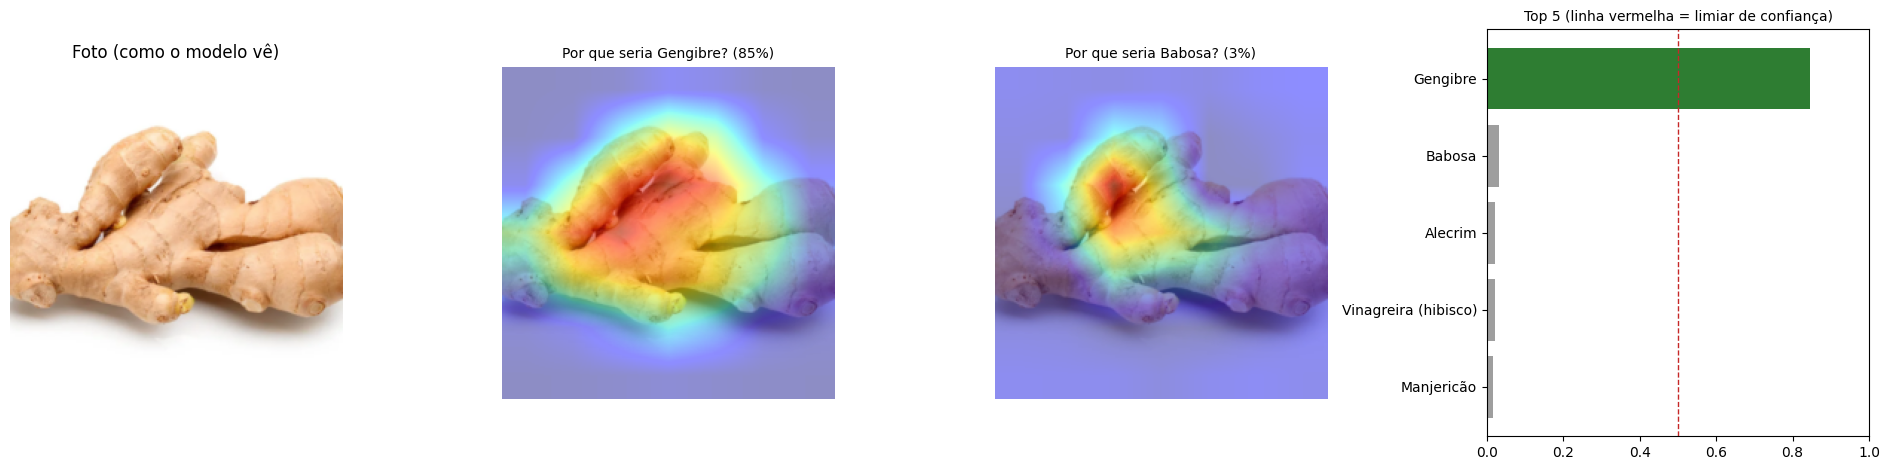

🌿 Planta identificada: Gengibre  (a IA pode errar, confirme antes de usar)
❓ Pergunta sobre Gengibre (em branco para parar): como preparalo


❓ Pergunta sobre Gengibre (em branco para parar): qual seria o melhor remedio para dor de garganta


❓ Pergunta sobre Gengibre (em branco para parar): 


In [17]:
# 16 · Demo completa
print("📷 Envie a foto da planta:")
enviado = files.upload()
planta = mostrar_gradcam(Image.open(list(enviado.keys())[0]))
if planta:
    print(f"🌿 Planta identificada: {planta}  (a IA pode errar, confirme antes de usar)")
while True:
    p = input(f"❓ Pergunta{f' sobre {planta}' if planta else ''} (em branco para parar): ").strip()
    if not p:
        break
    comparar(p, planta)

---
**Créditos:** fotos do iNaturalist (CC0, CC BY, CC BY-NC) · Grad-CAM: Selvaraju et al., *Grad-CAM: Visual Explanations from Deep Networks via Gradient-based Localization*, ICCV 2017 · Conteúdo do guia baseado no Formulário de Fitoterápicos da ANVISA · Modelos: EfficientNet-B0, multilingual-e5-base, Qwen2.5-3B-Instruct.

**Autor:** Pedro Henrique Campos Moreira · Sistemas de Informação · UFV Campus Rio Paranaíba